<a href="https://colab.research.google.com/github/gamzedrn/Softito-Egitim-Calismalari/blob/main/Palmer_Penguins_Dataset_for_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Keşifçi Veri Analizi (Exploratory Data Analysis - EDA)**

###  Kütüphanelerin Yüklenmesi

In [ ]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


## Veri yükleme

In [ ]:
df=sns.load_dataset('penguins')

print(' Penguen Verisi')
print('='*50)
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')
print('='*50)
print(f'Bellek kullanımı: {df.memory_usage(deep=True).sum()/1024:.2f} KB')


 Penguen Verisi
Boyut : 344 satır, 7 sütun
Bellek kullanımı: 65.96 KB


In [ ]:
#ilk beş satır yaazdırma
print('\n ilk 5 satır:')
df.head()


 ilk 5 satır:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.70,181.00,3750.00,Male
1,Adelie,Torgersen,39.50,17.40,186.00,3800.00,Female
2,Adelie,Torgersen,40.30,18.00,195.00,3250.00,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.70,19.30,193.00,3450.00,Female


In [ ]:
# son 5 satırı
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.80,14.30,215.00,4850.00,Female
341,Gentoo,Biscoe,50.40,15.70,222.00,5750.00,Male
342,Gentoo,Biscoe,45.20,14.80,212.00,5200.00,Female
343,Gentoo,Biscoe,49.90,16.10,213.00,5400.00,Male


In [ ]:
#rastgele beş satır
df.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
231,Gentoo,Biscoe,49.00,16.10,216.00,5550.00,Male
196,Chinstrap,Dream,50.90,17.90,196.00,3675.00,Female
287,Gentoo,Biscoe,49.50,16.20,229.00,5800.00,Male
340,Gentoo,Biscoe,46.80,14.30,215.00,4850.00,Female
65,Adelie,Biscoe,41.60,18.00,192.00,3950.00,Male


### **Veri Tipleri ve Temel İstatistikler**

In [ ]:
print('Penguen Verisi - Veri Tipleri')
print('='*50)

dtype_df = pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri': df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'unique': df.nunique().values
})

print(dtype_df.to_string(index=False))



Penguen Verisi - Veri Tipleri
            sütun veri tipi  null değeri  null oranı(%)  unique
          species    object            0           0.00       3
           island    object            0           0.00       3
   bill_length_mm   float64            2           0.58     164
    bill_depth_mm   float64            2           0.58      80
flipper_length_mm   float64            2           0.58      55
      body_mass_g   float64            2           0.58      94
              sex    object           11           3.20       2


In [ ]:
df.info() # detaylı veri bilgisi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.shape # boyut bilgisi

(344, 7)

In [ ]:
print(f'Bellek Kullanımı: {df.memory_usage(deep=True).sum()/1024:.2f} KB')

Bellek Kullanımı: 65.96 KB


In [ ]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.00,43.92,5.46,32.10,39.23,44.45,48.50,59.60
bill_depth_mm,342.00,17.15,1.97,13.10,15.60,17.30,18.70,21.50
flipper_length_mm,342.00,200.92,14.06,172.00,190.00,197.00,213.00,231.00
body_mass_g,342.00,4201.75,801.95,2700.00,3550.00,4050.00,4750.00,6300.00


In [ ]:
#kategorik  değişkenlerin temel istatistikleri
df.describe(include=['object','category']).T

,count,unique,top,freq
species,344,3,Adelie,152
island,344,3,Biscoe,168
sex,333,2,Male,168


In [ ]:
df2= pd.read_csv('/penguins.csv')

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [ ]:
# Sayısal değişkenler (int64 ve float64)
sayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(sayisal_sutunlar)

# Kategorik değişkenler (object ve category)
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(kategorik_sutunlar)

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
['species', 'island', 'sex']


## **Eksik Veri Analizi**

In [ ]:

# Eksik değerleri hesapla
eksik = df.isnull().sum()
eksik_orani = (eksik / len(df) * 100).round(2)

# DataFrame olarak birleştir
eksik_df = pd.concat([eksik, eksik_orani], axis=1)
eksik_df.columns = ["eksik_sayi", "eksik_oran"]

# En çok eksiği olandan en aza sırala
eksik_df = eksik_df.sort_values("eksik_oran", ascending=False)

# Sadece eksik olan sütunları göster
print("PENGUINS VERİSİ - EKSİK DEĞER ANALİZİ")
print("="*50)
print(eksik_df[eksik_df["eksik_sayi"] > 0])
print("="*50)

# Toplam eksik özeti
print(f"\nTOPLAM EKSİK HÜCRE: {df.isnull().sum().sum()}")
print(f"EKSİK ORANI: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

PENGUINS VERİSİ - EKSİK DEĞER ANALİZİ
                   eksik_sayi  eksik_oran
sex                        11        3.20
bill_depth_mm               2        0.58
bill_length_mm              2        0.58
flipper_length_mm           2        0.58
body_mass_g                 2        0.58

TOPLAM EKSİK HÜCRE: 19
EKSİK ORANI: 0.79%


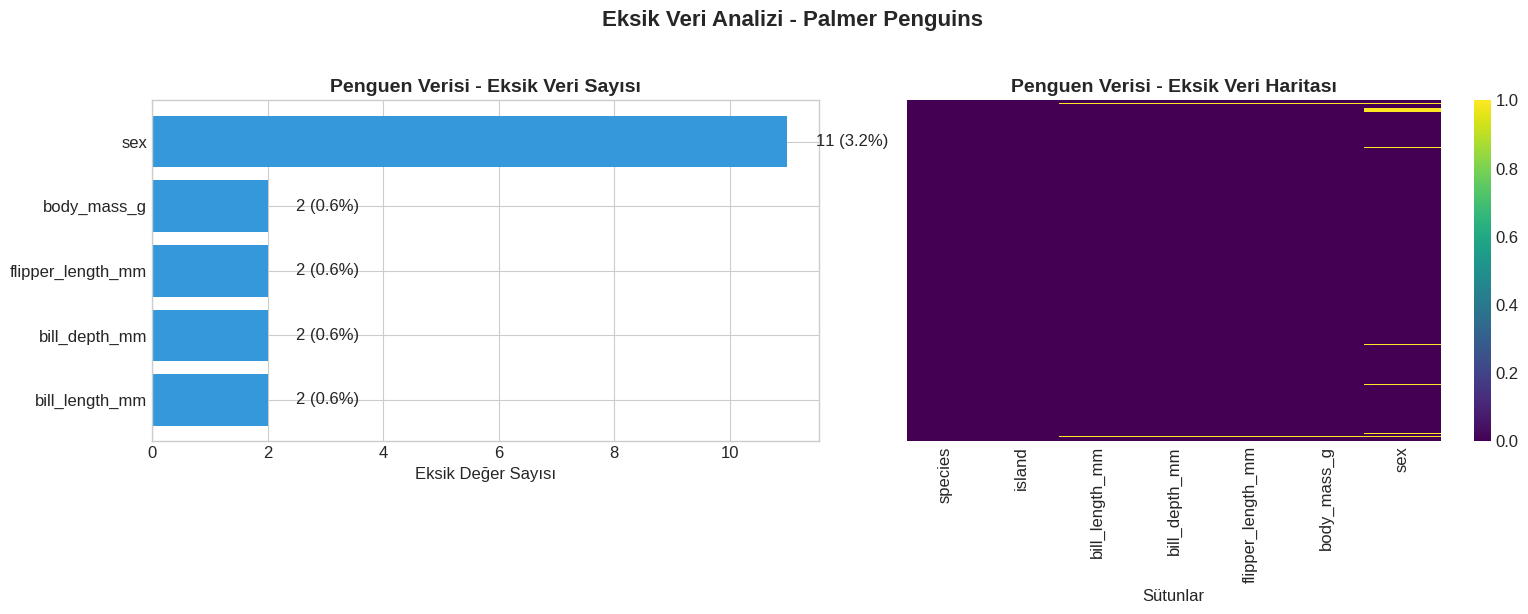


 EKSİK VERİ ÖZETİ
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
Toplam eksik hücre: 19
Eksik oranı: 0.79%


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. BAR CHART (Yatay Çubuk Grafik)
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

# Renk kodlaması: Kırmızı > %30, Turuncu > %10, Mavi < %10
colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Penguen Verisi - Eksik Veri Sayısı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')

# Çubukların üzerine sayı ve yüzde yaz
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 0.5, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# === 2. HEATMAP (Isı Haritası) ===
sns.heatmap(df.isnull(),
            yticklabels=False,  # 344 satır var, etiket gösterme
            cbar=True,
            cmap='viridis',     # Sarı = eksik, Lacivert = dolu
            ax=axes[1])
axes[1].set_title('Penguen Verisi - Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.suptitle('Eksik Veri Analizi - Palmer Penguins', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print(" EKSİK VERİ ÖZETİ")
print("="*50)
print(eksik_olan.to_string())
print("="*50)
print(f"Toplam eksik hücre: {df.isnull().sum().sum()}")
print(f"Eksik oranı: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

###  EKSİK VERİ STRATEJİLERİ



In [ ]:
# Orijinal veriyi bozma kopya
df_temiz = df.copy()

# Sayısal sütunları medyan ile doldur
sayisal_sutunlar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for kolon in sayisal_sutunlar:
    df_temiz[kolon].fillna(df_temiz[kolon].median(), inplace=True)

# Kategorik sütunu mod ile doldur
df_temiz['sex'].fillna(df_temiz['sex'].mode()[0], inplace=True)

# Kontrol et
print(f"Kalan eksik: {df_temiz.isnull().sum().sum()}")

Kalan eksik: 0


In [ ]:
# Mod  ile doldur - Cinsiyet sütunu için
sex_mode = df_temiz['sex'].mode()[0]
df_temiz['sex'].fillna(sex_mode, inplace=True)

# Doldurma sonrası kontrol
print("="*50)
print("MOD İLE DOLDURMA SONRASI EKSİK KONTROLÜ")
print("="*50)
print(df_temiz.isnull().sum())
print("="*50)
print(f"KALAN EKSİK HÜCRE SAYISI: {df_temiz.isnull().sum().sum()}")

MOD İLE DOLDURMA SONRASI EKSİK KONTROLÜ
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
KALAN EKSİK HÜCRE SAYISI: 0


In [ ]:
#deck sütun çok eksik var yeni bir feature ekle
df_temiz['deck']=df_temiz['deck'].astype(str).str[0]
df_temiz['deck'].fillna('Belirsiz',inplace=True)
print(df_temiz['deck'].value_counts())

## **Tek değişkenli analiz**

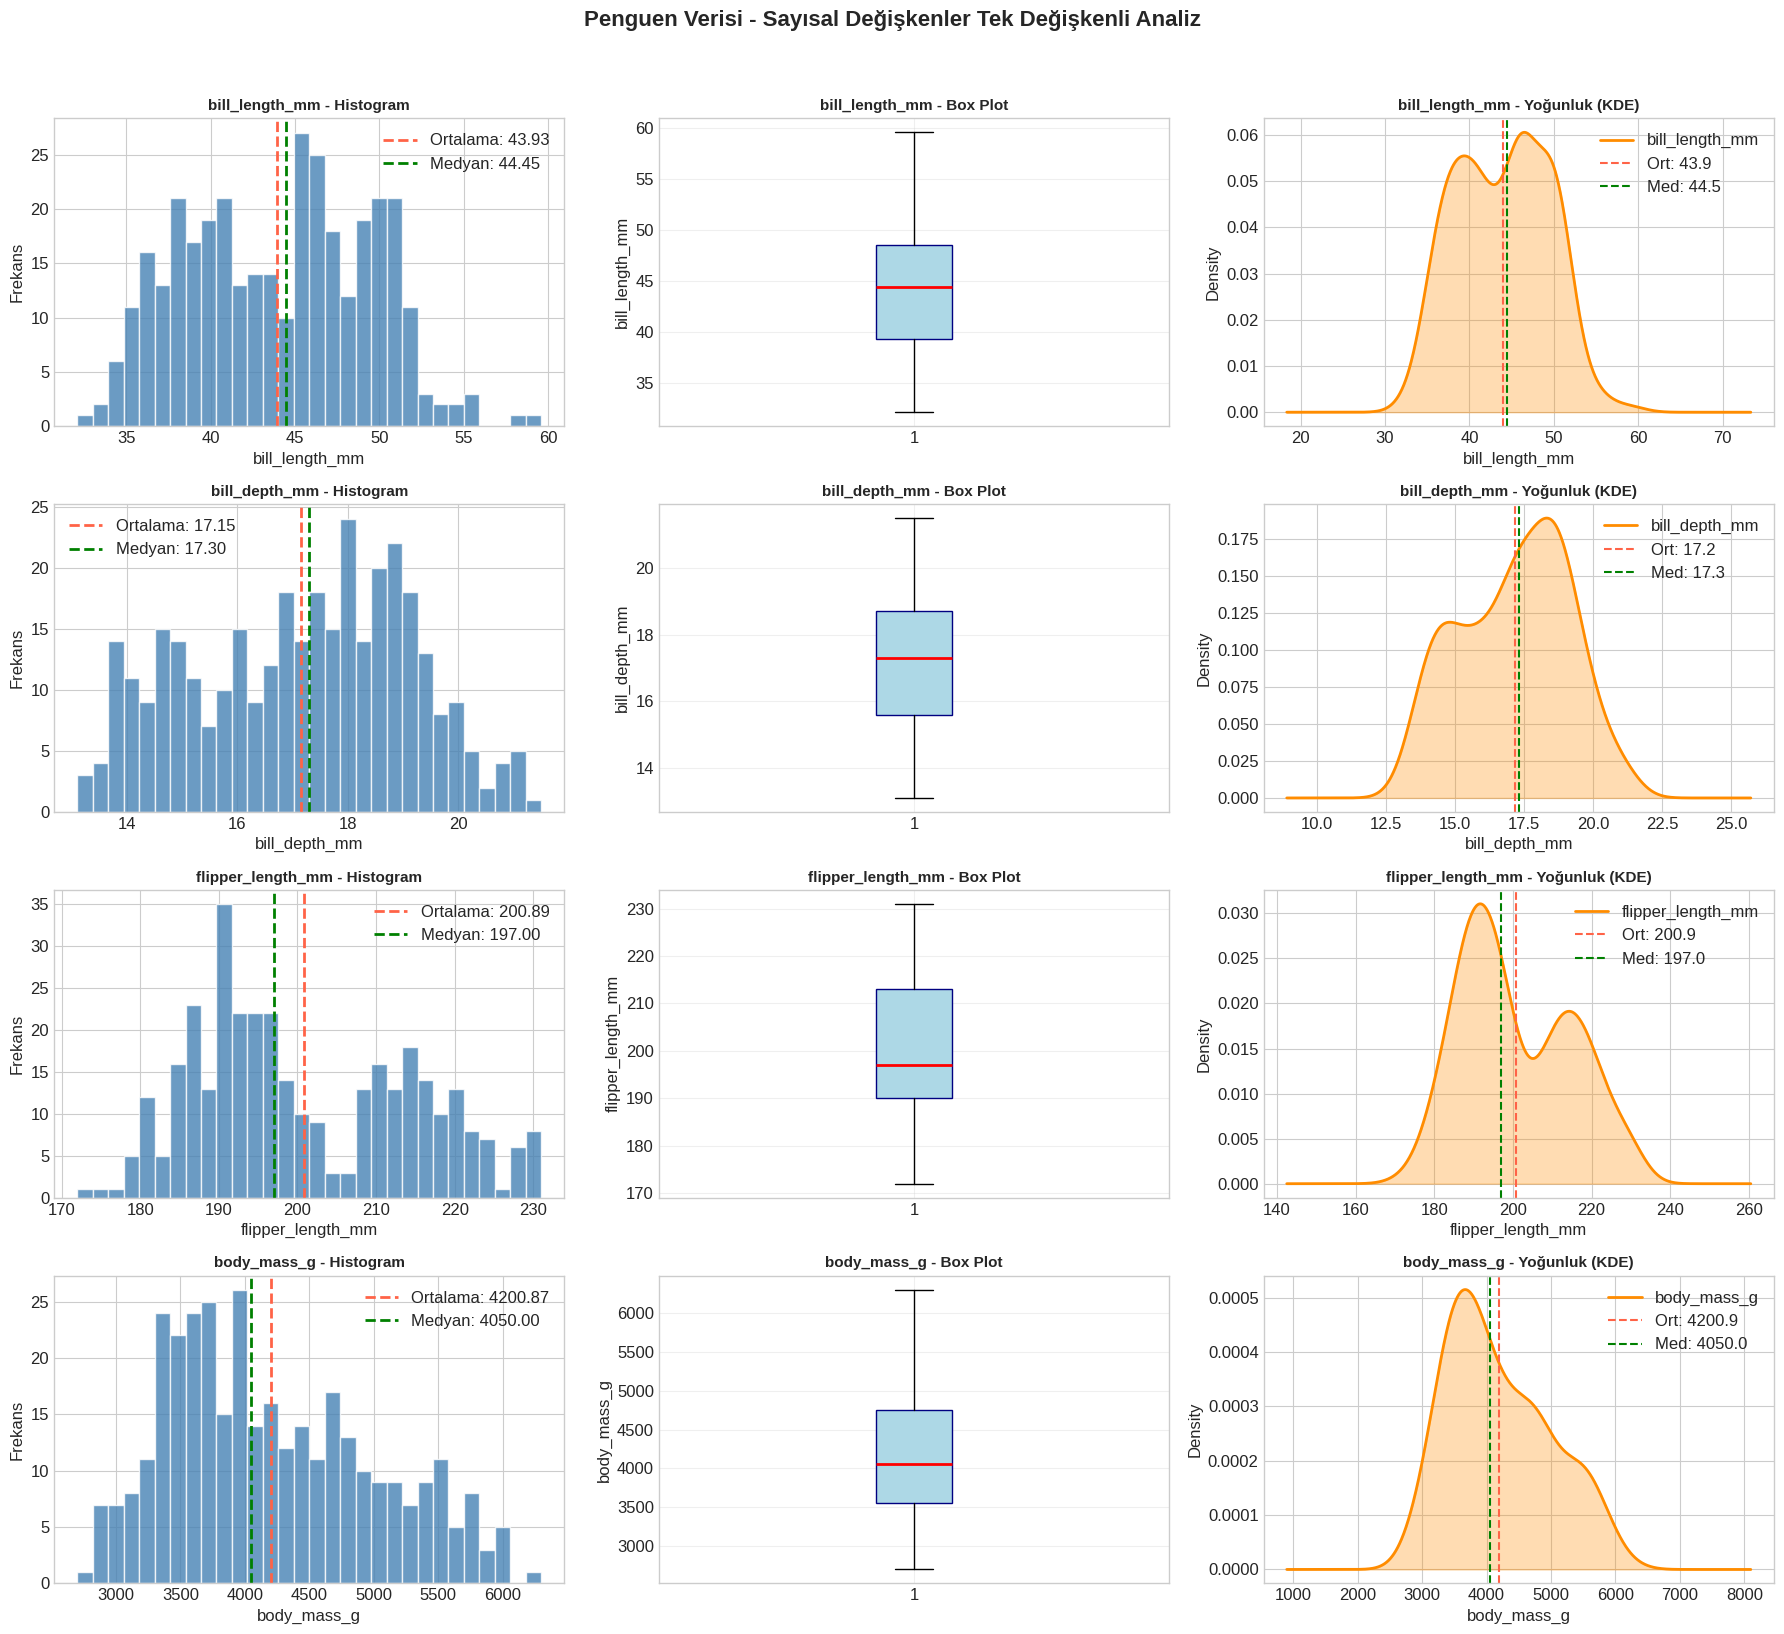

In [ ]:
# ============================================
# PENGUINS VERİSİ - TEK DEĞİŞKENLİ ANALİZ (Sayısal Değişkenler)
# ============================================

# Sayısal değişkenler
sayisal_kolonlar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 4*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    veri = df_temiz[kolon].dropna()

    # 1.HISTOGRAM
    axes[i,0].hist(veri, bins=30, color="steelblue", edgecolor='white', alpha=0.8)
    axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2,
                      label=f'Ortalama: {veri.mean():.2f}')
    axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2,
                      label=f'Medyan: {veri.median():.2f}')
    axes[i,0].set_title(f'{kolon} - Histogram', fontsize=11, fontweight='bold')
    axes[i,0].legend()
    axes[i,0].set_xlabel(kolon)
    axes[i,0].set_ylabel('Frekans')

    # 2. BOXPLOT (Kutu)
    axes[i,1].boxplot(veri, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2))
    axes[i,1].set_title(f'{kolon} - Box Plot', fontsize=11, fontweight='bold')
    axes[i,1].set_ylabel(kolon)
    axes[i,1].grid(True, alpha=0.3)

    # 3. KDE (Yoğunluk Grafiği)
    veri.plot.kde(ax=axes[i,2], color='darkorange', linewidth=2)
    axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                           axes[i,2].lines[0].get_ydata(),
                           color='darkorange', alpha=0.3)
    axes[i,2].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=1.5,
                      label=f'Ort: {veri.mean():.1f}')
    axes[i,2].axvline(veri.median(), color='green', linestyle='dashed', linewidth=1.5,
                      label=f'Med: {veri.median():.1f}')
    axes[i,2].set_title(f'{kolon} - Yoğunluk (KDE)', fontsize=11, fontweight='bold')
    axes[i,2].set_xlabel(kolon)
    axes[i,2].legend()

plt.suptitle('Penguen Verisi - Sayısal Değişkenler Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# PENGUINS VERİSİ - SAYISAL DEĞİŞKENLER İSTATİSTİKSEL ÖZET

# Sayısal değişkenler (Penguins için)
sayisal_kolonlar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

print('Penguen Verisi - Sayısal Değişkenler Detaylı İstatistikler')
print('='*70)

for kolon in sayisal_kolonlar:
    veri = df_temiz[kolon].dropna()

    print(f'\n{kolon.upper()}')
    print('-'*50)
    print(f'  Ortalama (Mean):               {veri.mean():.2f}')
    print(f'  Medyan (Median):               {veri.median():.2f}')
    print(f'  Standart Sapma (Std):          {veri.std():.2f}')
    print(f'  Minimum (Min):                 {veri.min():.2f}')
    print(f'  Maksimum (Max):                {veri.max():.2f}')
    print(f'  Varyans (Variance):            {veri.var():.2f}')
    print(f'  Çarpıklık (Skewness):          {veri.skew():.2f}')
    print(f'  Basıklık (Kurtosis):           {veri.kurtosis():.2f}')
    print(f'  IQR (Q3-Q1):                   {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
    print('='*70)

Penguen Verisi - Sayısal Değişkenler Detaylı İstatistikler

BILL_LENGTH_MM
--------------------------------------------------
  Ortalama (Mean):               43.93
  Medyan (Median):               44.45
  Standart Sapma (Std):          5.44
  Minimum (Min):                 32.10
  Maksimum (Max):                59.60
  Varyans (Variance):            29.63
  Çarpıklık (Skewness):          0.05
  Basıklık (Kurtosis):           -0.86
  IQR (Q3-Q1):                   9.23

BILL_DEPTH_MM
--------------------------------------------------
  Ortalama (Mean):               17.15
  Medyan (Median):               17.30
  Standart Sapma (Std):          1.97
  Minimum (Min):                 13.10
  Maksimum (Max):                21.50
  Varyans (Variance):            3.88
  Çarpıklık (Skewness):          -0.15
  Basıklık (Kurtosis):           -0.89
  IQR (Q3-Q1):                   3.10

FLIPPER_LENGTH_MM
--------------------------------------------------
  Ortalama (Mean):               200.89
  

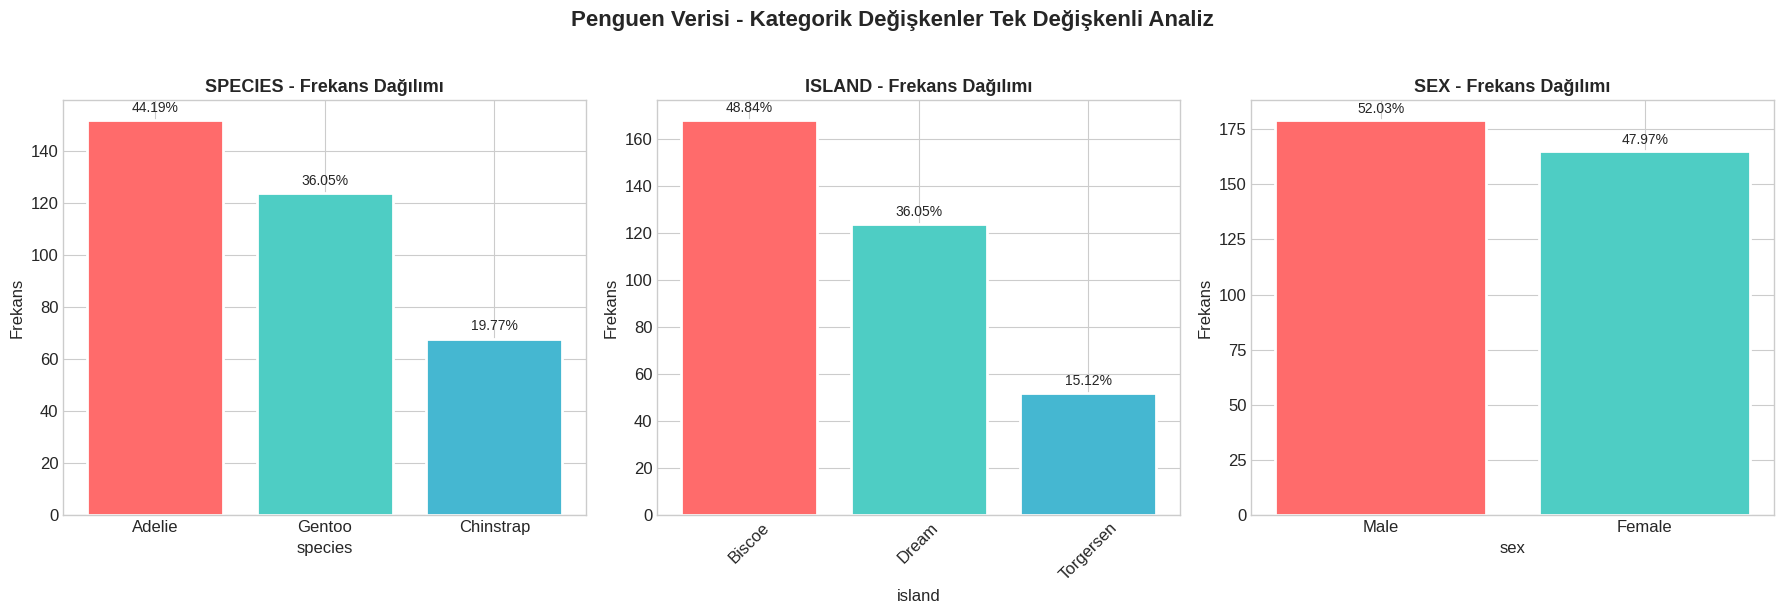


KATEGORİK DEĞİŞKENLER ÖZETİ

 SPECIES:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
Benzersiz değer sayısı: 3

 ISLAND:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
Benzersiz değer sayısı: 3

 SEX:
sex
Male      179
Female    165
Name: count, dtype: int64
Benzersiz değer sayısı: 2


In [ ]:
# PENGUINS VERİSİ - KATEGORİK DEĞİŞKENLER TEK DEĞİŞKENLİ ANALİZ


# Penguins için kategorik değişkenler
kategorik_kolonlar = ['species', 'island', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 3 değişken için 1 satır, 3 sütun

# Renk paleti
renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595']

for i, kolon in enumerate(kategorik_kolonlar):
    degerler = df_temiz[kolon].value_counts()
    yuzde = (degerler / len(df_temiz) * 100).round(2)

    # Bar chart
    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)

    # Başlık ve etiketler
    axes[i].set_title(f'{kolon.upper()} - Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')
    axes[i].tick_params(axis='x', rotation=45 if kolon == 'island' else 0)

    # Çubukların üzerine yüzde
    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 2,
                     f'{pct}%',
                     ha='center',
                     va='bottom',
                     fontsize=10)

plt.suptitle('Penguen Verisi - Kategorik Değişkenler Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("KATEGORİK DEĞİŞKENLER ÖZETİ")
print("="*50)

for kolon in kategorik_kolonlar:
    print(f"\n {kolon.upper()}:")
    print(df_temiz[kolon].value_counts())
    print(f"Benzersiz değer sayısı: {df_temiz[kolon].nunique()}")

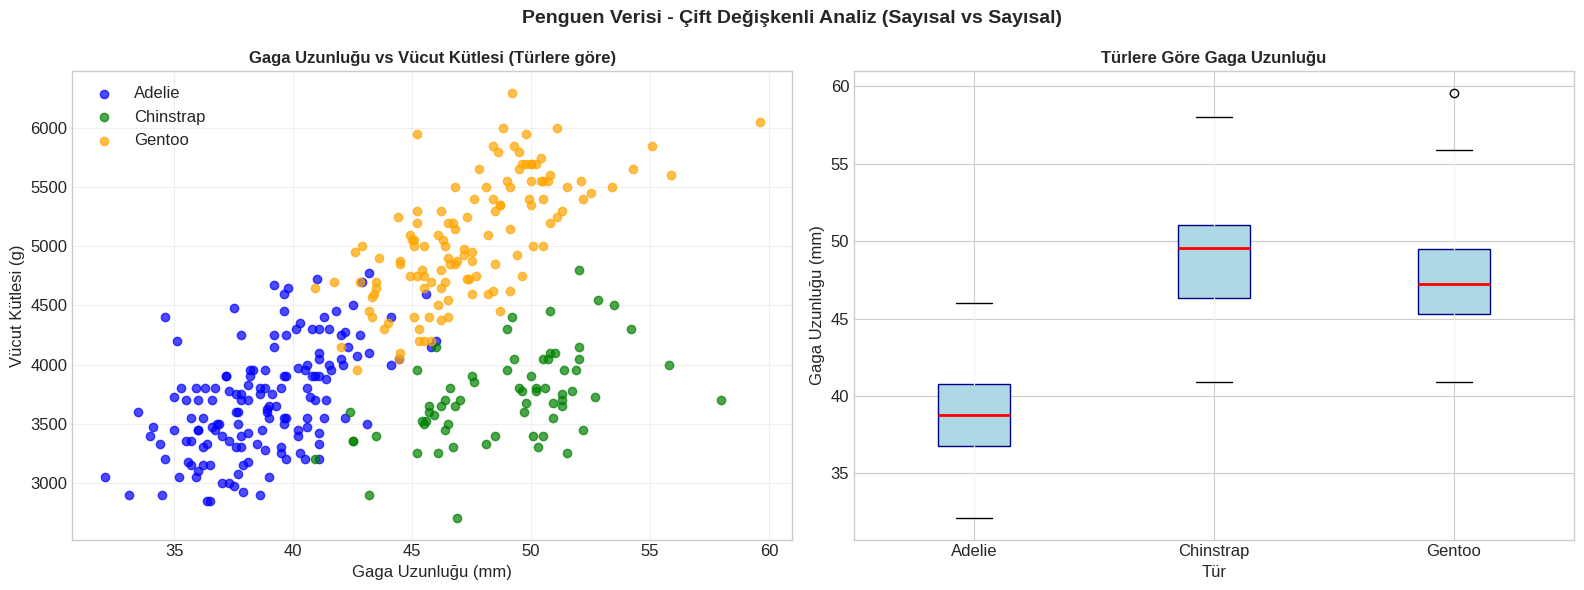

In [ ]:
# PENGUINS VERİSİ - SAYISAL vs SAYISAL (Scatter Plot & Box Plot)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SCATTER PLOT: Gaga Uzunluğu vs Vücut Kütlesi (Türlere göre renklendirilmiş)

türler = df_temiz['species'].unique()
renkler = {'Adelie': 'blue', 'Chinstrap': 'green', 'Gentoo': 'orange'}

for tur in türler:
    veri = df_temiz[df_temiz['species'] == tur]
    axes[0].scatter(veri['bill_length_mm'], veri['body_mass_g'],
                    color=renkler[tur], label=tur, alpha=0.7)

axes[0].set_xlabel('Gaga Uzunluğu (mm)')
axes[0].set_ylabel('Vücut Kütlesi (g)')
axes[0].set_title('Gaga Uzunluğu vs Vücut Kütlesi (Türlere göre)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BOX PLOT: Tür vs Gaga Uzunluğu

df_temiz.boxplot(column='bill_length_mm', by='species', ax=axes[1], patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='navy'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('Tür')
axes[1].set_ylabel('Gaga Uzunluğu (mm)')
axes[1].set_title('Türlere Göre Gaga Uzunluğu', fontsize=12, fontweight='bold')

plt.suptitle('Penguen Verisi - Çift Değişkenli Analiz (Sayısal vs Sayısal)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

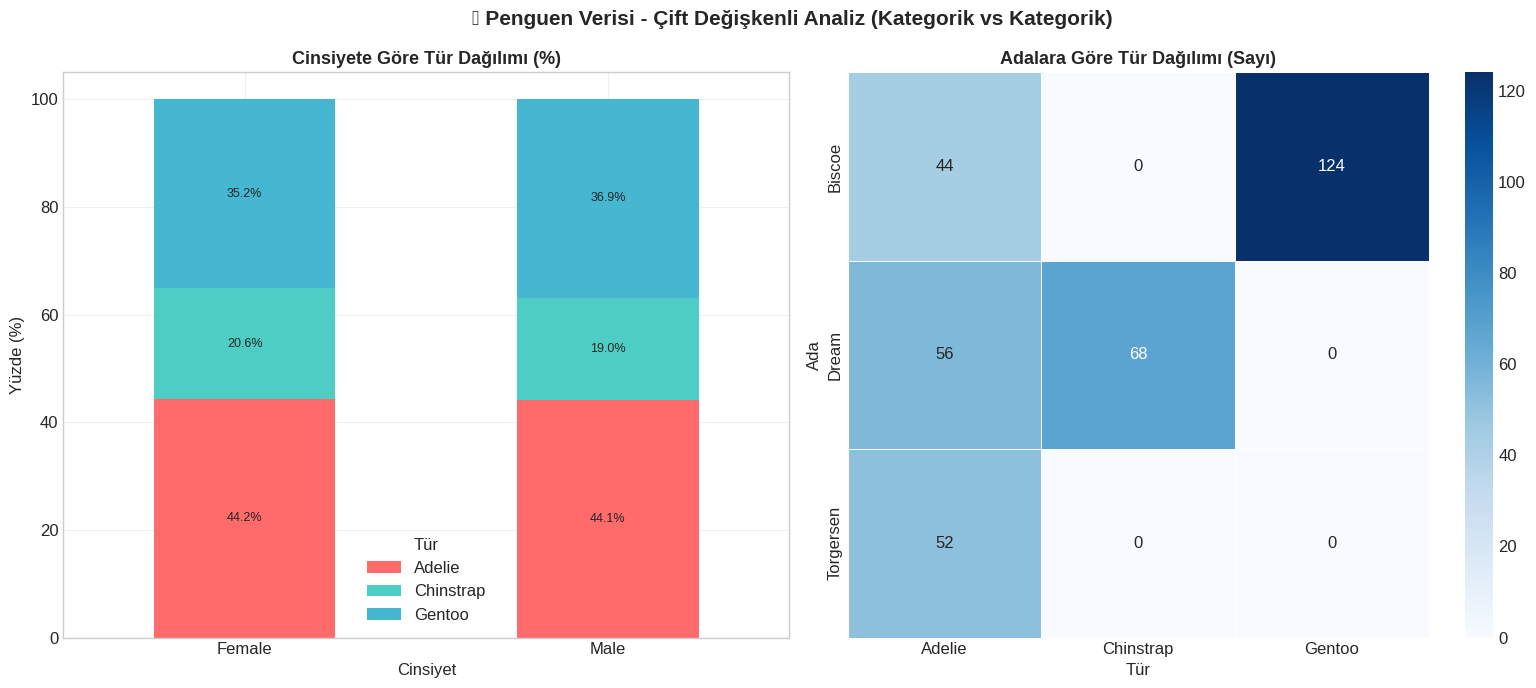


KATEGORİK vs KATEGORİK ANALİZ ÖZETİ

Cinsiyet × Tür (Yüzde):
species  Adelie  Chinstrap  Gentoo
sex                               
Female    44.20      20.60   35.20
Male      44.10      19.00   36.90

Ada × Tür (Sayı):
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     124
Dream          56         68       0
Torgersen      52          0       0


In [ ]:
# PENGUINS VERİSİ - KATEGORİK vs KATEGORİK ANALİZ


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# CİNSİYET vs TÜR (Yığılmış Bar Chart)
ct_pct = pd.crosstab(df_temiz['sex'], df_temiz['species'], normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])

axes[0].set_title('Cinsiyete Göre Tür Dağılımı (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cinsiyet')
axes[0].set_ylabel('Yüzde (%)')
axes[0].legend(title='Tür')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(True, alpha=0.3)

# Çubukların üzerine yüzde değerlerini yaz
for i, (idx, row) in enumerate(ct_pct.iterrows()):
    cumsum = 0
    for j, (col, val) in enumerate(row.items()):
        if val > 5:  # Sadece okunabilir değerleri yaz
            axes[0].text(i, cumsum + val/2, f'{val:.1f}%', ha='center', va='center', fontsize=9)
        cumsum += val

# ADA vs TÜR (Isı Haritası)

ct2 = pd.crosstab(df_temiz['island'], df_temiz['species'])
ct2.columns = ['Adelie', 'Chinstrap', 'Gentoo']
ct2.index = ['Biscoe', 'Dream', 'Torgersen']

sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Adalara Göre Tür Dağılımı (Sayı)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tür')
axes[1].set_ylabel('Ada')

plt.suptitle('🐧 Penguen Verisi - Çift Değişkenli Analiz (Kategorik vs Kategorik)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("KATEGORİK vs KATEGORİK ANALİZ ÖZETİ")
print("="*50)

print("\nCinsiyet × Tür (Yüzde):")
print(pd.crosstab(df_temiz['sex'], df_temiz['species'], normalize='index').round(3) * 100)

print("\nAda × Tür (Sayı):")
print(pd.crosstab(df_temiz['island'], df_temiz['species']))

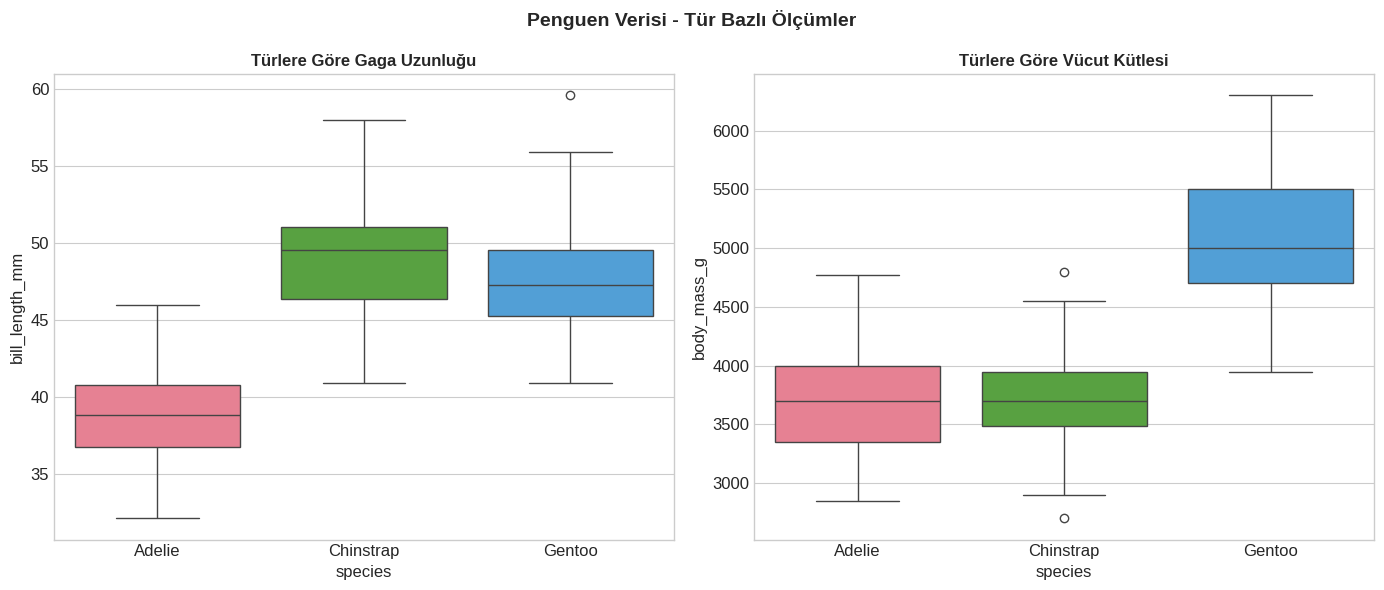

In [ ]:
# PENGUINS - EN ÖNEMLİ 2 GRAFİK

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Tür vs Gaga Uzunluğu
sns.boxplot(data=df_temiz, x='species', y='bill_length_mm', ax=axes[0], palette='husl')
axes[0].set_title('Türlere Göre Gaga Uzunluğu', fontsize=12, fontweight='bold')

# 2. Tür vs Vücut Kütlesi
sns.boxplot(data=df_temiz, x='species', y='body_mass_g', ax=axes[1], palette='husl')
axes[1].set_title('Türlere Göre Vücut Kütlesi', fontsize=12, fontweight='bold')

plt.suptitle('Penguen Verisi - Tür Bazlı Ölçümler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()